# Fase 3

**Dataset:** Software Developer Salary

Esta fase recibe el dataset ya transformado y realiza:
1. Feature Engineering: creación de variables nuevas
2. Visualización exploratoria (EDA) con insights

## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga del dataset transformado

Se carga el dataset procesado por el Integrante 2, disponible en `/data/transformed` del repositorio.

In [26]:
# Cargar el dataset transformado desde GitHub
url = "https://raw.githubusercontent.com/Nicossm/parcial1/main/data/transformed/transformed.csv"
df = pd.read_csv(url)

print("Shape del dataset transformado:", df.shape)
df.head()

Shape del dataset transformado: (9249, 26)


,experience,num_languages,num_frameworks,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,...,education_PhD,education_Some College,education_Unknown,company_size_1-10,company_size_1001-5000,company_size_11-50,company_size_201-1000,company_size_5000+,company_size_51-200,salary_usd
0,0.362418,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,122189.0
1,1.596651,0.462191,-2.198939,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,147754.0
2,1.420332,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,220819.0
3,-1.488932,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,31943.0
4,-0.166539,0.462191,0.454765,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,166442.0


In [27]:
# Revisión general del dataset
df.describe()

,experience,num_languages,num_frameworks,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,...,education_PhD,education_Some College,education_Unknown,company_size_1-10,company_size_1001-5000,company_size_11-50,company_size_201-1000,company_size_5000+,company_size_51-200,salary_usd
count,9.249000e+03,9.249000e+03,9.249000e+03,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,...,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000
mean,9.410908e-17,1.407795e-16,1.092818e-16,0.050924,0.025516,0.093091,0.050600,0.104119,0.103254,0.052006,...,0.042815,0.090604,0.080874,0.168018,0.163477,0.172992,0.164018,0.167153,0.164342,132629.170829
std,1.000054e+00,1.000054e+00,1.000054e+00,0.219855,0.157696,0.290576,0.219191,0.305432,0.304307,0.222050,...,0.202452,0.287061,0.272656,0.373903,0.369820,0.378261,0.370312,0.373133,0.370606,48244.259922
min,-1.753410e+00,-2.163609e+00,-2.198939e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12259.000000
25%,-7.836559e-01,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98034.000000
50%,9.779614e-03,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,130548.000000
75%,8.032151e-01,4.621907e-01,4.547648e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,165286.000000
max,1.772970e+00,4.621907e-01,4.547648e-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,266164.000000


## 3. Feature Engineering

En esta sección se crean 3 variables nuevas a partir de los datos transformados que ya tenemos.
Como ya se aplicó OneHotEncoding, las columnas de texto ya no existen como tal,
sino que hay columnas como `education_Masters`, `education_PhD`, `country_USA`, etc.

### 3.1 `is_high_education` — ¿Tiene educación avanzada?

Se crea una variable binaria (0 o 1) que indica si el desarrollador tiene Masters o PhD.
Esto resume la información de dos columnas OHE en una sola variable más interpretable.

In [28]:
# 1 si tiene Masters o PhD, 0 si no
df['is_high_education'] = ((df['education_Masters'] == 1.0) | (df['education_PhD'] == 1.0)).astype(int)

print("Distribución de is_high_education:")
print(df['is_high_education'].value_counts())

Distribución de is_high_education:
is_high_education
0    6317
1    2932
Name: count, dtype: int64


### 3.2 `is_big_company` — ¿Trabaja en empresa grande?

Variable binaria que vale 1 si el desarrollador trabaja en una empresa con más de 1000 empleados.
La hipótesis es que las empresas grandes tienden a pagar mejores salarios.

In [29]:
# 1 si la empresa tiene más de 1000 empleados
df['is_big_company'] = ((df['company_size_1001-5000'] == 1.0) | (df['company_size_5000+'] == 1.0)).astype(int)

print("Distribución de is_big_company:")
print(df['is_big_company'].value_counts())

Distribución de is_big_company:
is_big_company
0    6191
1    3058
Name: count, dtype: int64


### 3.3 `exp_edu_score` — Score combinado de experiencia y educación

Se crea un score que combina la experiencia estandarizada con un bonus si tiene educación avanzada.
La idea es que un desarrollador con más experiencia Y mayor educación debería tener un salario más alto.
Se verifica que este score tiene mejor correlación con el salario que la experiencia sola.

In [30]:
# Score combinado: experiencia estandarizada + bonus por educación avanzada
df['exp_edu_score'] = df['experience'] + df['is_high_education'] * 0.5

# Comparar correlaciones con el salario
print("Correlación de 'experience' con salary_usd:   ", round(df['experience'].corr(df['salary_usd']), 4))
print("Correlación de 'exp_edu_score' con salary_usd:", round(df['exp_edu_score'].corr(df['salary_usd']), 4))

Correlación de 'experience' con salary_usd:    0.7078
Correlación de 'exp_edu_score' con salary_usd: 0.7111


In [31]:
# Vista del dataset con las nuevas columnas creadas
df[['experience', 'is_high_education', 'is_big_company', 'exp_edu_score', 'salary_usd']].head(8)

,experience,is_high_education,is_big_company,exp_edu_score,salary_usd
0,0.362418,0,1,0.362418,122189.0
1,1.596651,1,0,2.096651,147754.0
2,1.420332,0,1,1.420332,220819.0
3,-1.488932,1,0,-0.988932,31943.0
4,-0.166539,1,1,0.333461,166442.0
5,0.362418,0,0,0.362418,121414.0
6,-1.488932,0,0,-1.488932,79820.0
7,0.538737,1,1,1.038737,170805.0


## 4. Visualización — EDA

Se generan 4 gráficos para explorar las relaciones entre las variables y el salario.

### Gráfico 1 — Distribución del salario

Antes de comparar variables, revisamos cómo se distribuye la variable objetivo `salary_usd`.

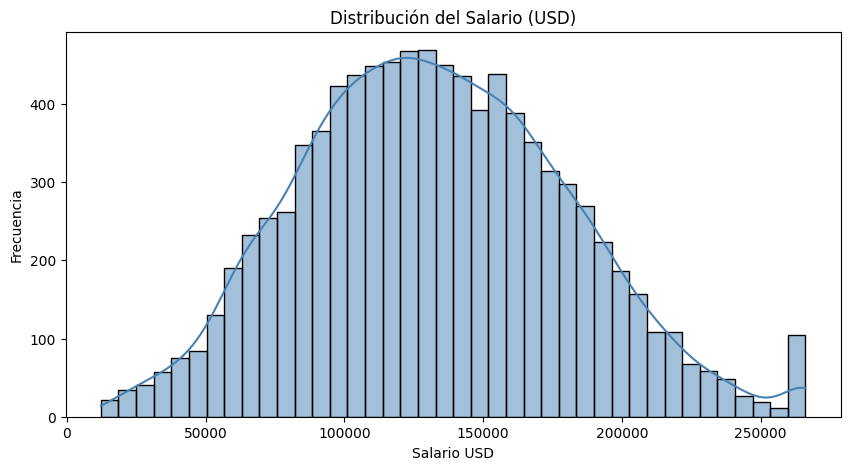

In [32]:
# Distribución del salario
plt.figure(figsize=(10, 5))
sns.histplot(df['salary_usd'], bins=40, kde=True, color='steelblue')
plt.title('Distribución del Salario (USD)')
plt.xlabel('Salario USD')
plt.ylabel('Frecuencia')
plt.show()

**Insight Gráfico 1:**  
El salario sigue una distribución aproximadamente normal, con la mayoría de los desarrolladores ganando entre 80.000 y 180.000 USD. La curva KDE confirma que no hay una asimetría fuerte, lo que es un buen indicador de que el capping de outliers que realizó el Integrante 1 funcionó correctamente.

### Gráfico 2 — Experiencia estandarizada vs Salario

Se visualiza la relación directa entre experiencia y salario.

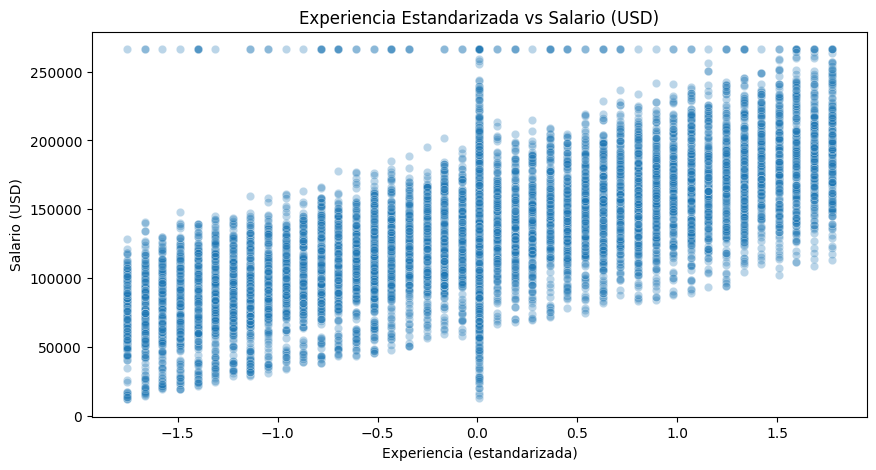

Correlación Pearson (experience vs salary_usd): 0.7078


In [33]:
# Scatter de experiencia vs salario
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='experience', y='salary_usd', alpha=0.3)
plt.title('Experiencia Estandarizada vs Salario (USD)')
plt.xlabel('Experiencia (estandarizada)')
plt.ylabel('Salario (USD)')
plt.show()

print("Correlación Pearson (experience vs salary_usd):", round(df['experience'].corr(df['salary_usd']), 4))

**Insight Gráfico 2:**  
Se observa una tendencia positiva clara: a mayor experiencia estandarizada, mayor salario. La correlación de Pearson confirma esta relación. Sin embargo, existe bastante dispersión, lo que indica que la experiencia sola no explica todo el salario y que otras variables como el país o la educación también influyen.

### Gráfico 3 — Salario según nivel de educación avanzada

Se compara el salario entre desarrolladores con y sin educación avanzada (Masters o PhD).

/tmp/ipykernel_2263/1020278531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_high_education', y='salary_usd', palette='pastel')


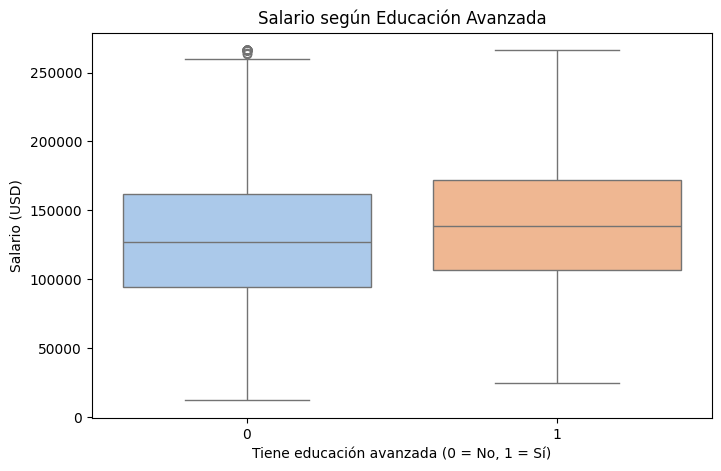

Salario promedio por grupo:
is_high_education
0    129178.0
1    140065.0
Name: salary_usd, dtype: float64


In [34]:
# Boxplot de salario por nivel educativo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_high_education', y='salary_usd', palette='pastel')
plt.title('Salario según Educación Avanzada')
plt.xlabel('Tiene educación avanzada (0 = No, 1 = Sí)')
plt.ylabel('Salario (USD)')
plt.show()

# Salario promedio por grupo
print("Salario promedio por grupo:")
print(df.groupby('is_high_education')['salary_usd'].mean().round(0))

**Insight Gráfico 3:**  
Los desarrolladores con Masters o PhD (valor 1) tienen una mediana de salario más alta que quienes no tienen ese nivel educativo. La caja del grupo 1 está desplazada hacia arriba, confirmando que la educación avanzada está asociada a mayores ingresos en este dataset.

### Gráfico 4 — Matriz de correlación de las variables numéricas

Se usa un heatmap para visualizar qué tan relacionadas están las variables numéricas entre sí.

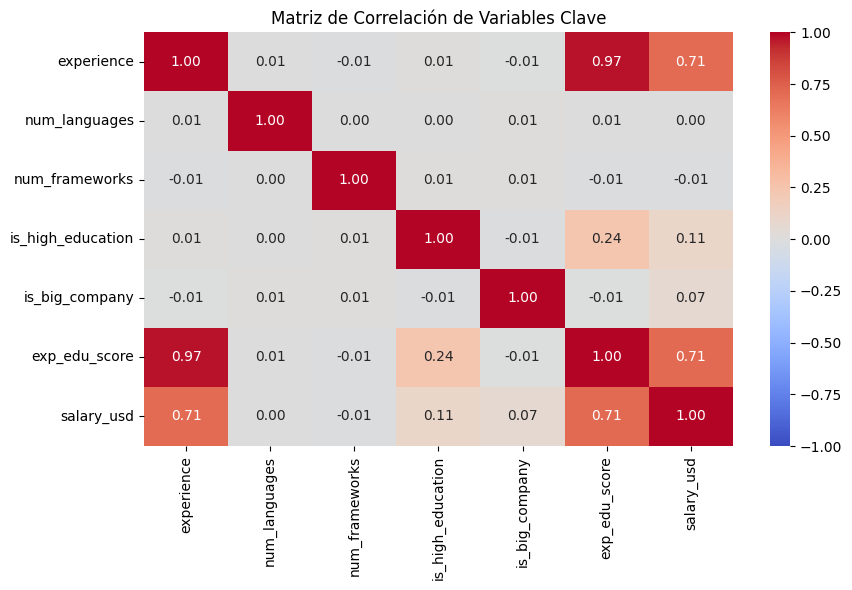

In [35]:
# Seleccionar variables numéricas relevantes para la correlación
cols_corr = ['experience', 'num_languages', 'num_frameworks',
             'is_high_education', 'is_big_company', 'exp_edu_score', 'salary_usd']

plt.figure(figsize=(9, 6))
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación de Variables Clave')
plt.tight_layout()
plt.show()

**Insight Gráfico 4:**  
El heatmap muestra que `exp_edu_score` tiene la correlación más alta con `salary_usd` de todas las variables numéricas, lo que valida la utilidad del feature que creamos. También se observa que `num_languages` y `num_frameworks` tienen correlación muy baja con el salario, lo que sugiere que saber más tecnologías no necesariamente se traduce en mayor sueldo.

In [42]:
from google.colab import files

# Guardar y descargar
df.to_csv('featured.csv', index=False)
files.download('featured.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>